# BERToscope, Part 3 — Can attention find collocations?

Attention weights are sometimes read as if they were explanations: "the model attends from X to Y, therefore it understands the X-Y relationship." This notebook puts that reading to a direct test using lexical collocations -- word pairs like "strong tea" or "make a decision" whose association is conventional, not merely compositional.

For each curated sentence, we compare the attention weight between the collocated pair against the attention weight between one of those words and an unrelated control word in the same sentence, across all 12 layers x 12 heads of `bert-base-uncased`. The honest version of this experiment also has to ask: is any effect we see actually about lexical association, or just about adjacency?

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import json

with open(REPO_ROOT / "data" / "collocations.json") as f:
    items = json.load(f)["items"]

len(items), items[0]

(15,
 {'id': 'c1',
  'relation': 'amod+noun',
  'sentence': 'She always drinks strong tea in the morning.',
  'word_a': 'strong',
  'word_b': 'tea',
  'control_word': 'morning'})

In [3]:
import pandas as pd

from attention.collocation import find_word_token_span, load_attention_model, word_pair_attention

tokenizer, model = load_attention_model("bert-base-uncased")

rows = []
for item in items:
    colloc_attn = word_pair_attention(tokenizer, model, item["sentence"], item["word_a"], item["word_b"])
    control_attn = word_pair_attention(
        tokenizer, model, item["sentence"], item["word_a"], item["control_word"]
    )

    span_a = find_word_token_span(tokenizer, item["sentence"], item["word_a"])
    span_b = find_word_token_span(tokenizer, item["sentence"], item["word_b"])
    span_c = find_word_token_span(tokenizer, item["sentence"], item["control_word"])
    colloc_distance = abs(span_a[0] - span_b[0])
    control_distance = abs(span_a[0] - span_c[0])

    num_layers, num_heads = colloc_attn.shape
    for layer in range(num_layers):
        for head in range(num_heads):
            rows.append(
                {
                    "item_id": item["id"],
                    "layer": layer,
                    "head": head,
                    "kind": "collocation",
                    "weight": colloc_attn[layer, head].item(),
                    "distance": colloc_distance,
                }
            )
            rows.append(
                {
                    "item_id": item["id"],
                    "layer": layer,
                    "head": head,
                    "kind": "control",
                    "weight": control_attn[layer, head].item(),
                    "distance": control_distance,
                }
            )

attn_df = pd.DataFrame(rows)
attn_df.head()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,item_id,layer,head,kind,weight,distance
0,c1,0,0,collocation,0.075872,1
1,c1,0,0,control,0.090496,4
2,c1,0,1,collocation,0.136589,1
3,c1,0,1,control,0.172254,4
4,c1,0,2,collocation,0.182835,1


In [4]:
mean_by_kind = attn_df.groupby(["layer", "head", "kind"])["weight"].mean().unstack("kind")
gap_matrix = (mean_by_kind["collocation"] - mean_by_kind["control"]).unstack("head")
gap_matrix.index.name = "layer"
gap_matrix.columns.name = "head"
gap_matrix

head,0,1,2,3,4,5,6,7,8,9,10,11
layer,,,,,,,,,,,,
0,-0.023639,0.032187,0.335268,0.229024,-0.003192,0.203962,0.008066,0.011686,0.016795,0.048763,0.487338,0.208834
1,-0.005227,0.311052,0.014158,-0.003430,0.147916,0.001796,0.001154,-0.002961,-0.026087,-0.008985,0.156006,0.018899
2,0.399959,0.475392,0.007500,-0.017599,0.057020,0.015203,0.021535,-0.011463,-0.000630,0.399953,0.045084,0.034214
3,0.000281,-0.013576,0.010250,-0.002507,0.010603,0.155502,0.040481,0.000774,0.072292,0.394995,0.328670,0.036600
4,0.109255,-0.003986,0.000717,0.000442,0.020329,0.142907,0.057292,0.275087,0.003258,0.020070,0.030970,0.097147
5,0.042565,0.109918,-0.003883,0.017140,0.018186,0.004931,0.096316,0.167730,-0.008479,0.346383,0.098318,0.015497
6,0.012461,-0.009952,0.022055,0.068779,0.129640,0.262143,0.084560,-0.009199,0.023117,0.085419,0.044577,0.179832
7,-0.001109,0.034962,0.055142,0.049007,0.134268,0.036189,0.031702,0.010331,0.013321,0.056670,0.229960,0.028295
8,0.006537,0.014698,0.043779,0.016023,0.003733,0.040045,0.015674,-0.012149,0.003382,0.042383,0.028567,0.027313


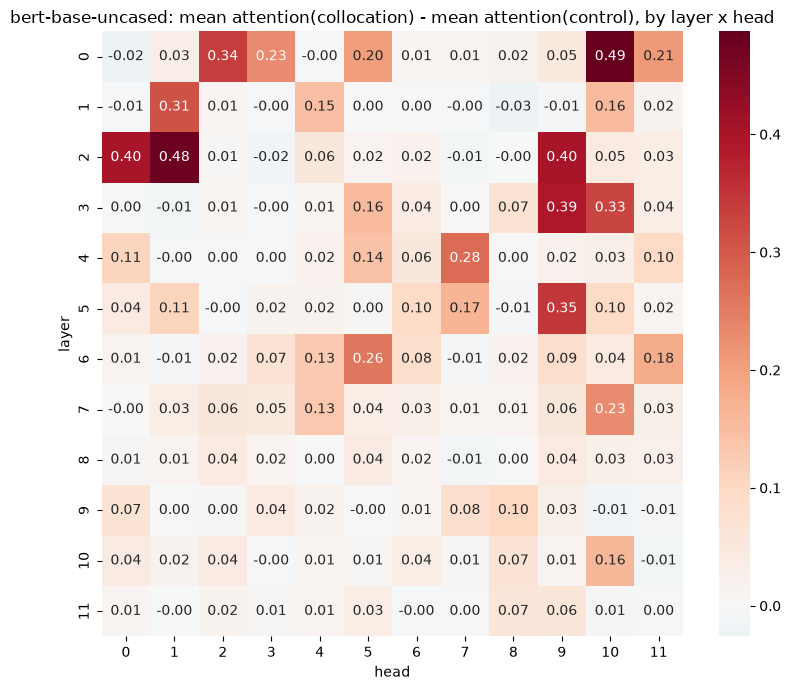

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(gap_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("bert-base-uncased: mean attention(collocation) - mean attention(control), by layer x head")
fig.tight_layout()

In [6]:
top_heads = gap_matrix.stack().sort_values(ascending=False).head(10)
top_heads

layer  head
0      10      0.487338
2      1       0.475392
       0       0.399959
       9       0.399953
3      9       0.394995
5      9       0.346383
0      2       0.335268
3      10      0.328670
1      1       0.311052
4      7       0.275087
dtype: float64

### Controlling for the adjacency confound

Collocated word pairs are almost always adjacent in these sentences ("strong tea", "make a decision"), while control pairs are picked from elsewhere in the sentence and are usually farther apart. Any collocation > control gap above could just be BERT's well-documented bias toward attending to nearby tokens, not genuine lexical association.

In [7]:
attn_df.groupby("kind")["distance"].describe()

,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
collocation,2160.0,1.2,0.400093,1.0,1.0,1.0,1.0,2.0
control,2160.0,4.2,1.045868,2.0,4.0,4.0,5.0,6.0


In [8]:
from scipy.stats import pearsonr

corr, _p = pearsonr(attn_df["distance"], attn_df["weight"])
corr

np.float64(-0.3074734115026527)

### Finding

The top 10 (layer, head) cells by collocation-minus-control attention gap are dominated by **early layers**: layer 0 (heads 2, 10), layer 1 (head 1), layer 2 (heads 0, 1, 9), layer 3 (heads 9, 10), layer 4 (head 7), layer 5 (head 9) — gaps ranging from 0.275 to 0.487. No layer past 5 makes the top 10.

But the adjacency confound is real and large: collocation pairs sit at a mean token distance of 1.2 (almost always literally adjacent), while control pairs sit at a mean distance of 4.2 — and attention weight correlates with distance at r = -0.31 across the whole dataset. BERT's well-documented locality bias (attending more to nearby tokens regardless of what they mean) is doing real work here.

**Honest verdict:** the heads that look like "collocation detectors" cluster in exactly the early layers where the literature (e.g. Tenney et al., *BERT Rediscovers the Classical NLP Pipeline*) already places positional/syntactic pattern-matching, not lexical-semantic association. Combined with the distance confound, this is consistent with attention picking up "these tokens are next to each other," not "these two words form a conventional unit." Nothing in this sweep shows a head that tracks lexical association independent of proximity — which is itself the finding. Attention weight is not evidence of semantic understanding; treating a high attention score as "the model knows these words go together" would be reading explanation into a pattern that adjacency alone mostly explains.